In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!pip install xgboost catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:07
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:07
   ---------------------------------------- 0.8/101.7 MB 1.0 MB/s eta 0:01:37
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 1.3/101.7 MB 1.2 MB/s eta 0:01:23
    --------------------------------------- 1.8/101.7 MB 1.3 MB/s eta 0:01:19
    --------------------------------------- 2.1/101.7 MB 1.3 MB/s eta 0:01:14
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:07
   - -------------------------------------- 3.1/101.7 MB 1.6 MB/s eta 0:01:04
   - -------------------------------------- 3.4/101.7 MB 1.6 MB/s eta 0:01:03
   - -------------------------------------- 3.7/101.7 MB 1.6 MB/s eta 0:01:03


In [3]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import warnings

In [6]:
df=pd.read_csv("data/StudentsPerformance.csv")

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
x=df.drop(columns=['math score'],axis=1)

In [10]:
y=df['math score']

In [11]:
numerical_features=x.select_dtypes(exclude="object").columns
categorical_features=x.select_dtypes(include="object").columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_transformer=StandardScaler()
OH_transformer=OneHotEncoder()

preproccesor=ColumnTransformer(
[
    ("OneHotEncoder",OH_transformer,categorical_features),
    ("StandardScaler",numerical_transformer,numerical_features),
])

In [14]:
x=preproccesor.fit_transform(x)

In [15]:
x.shape

(1000, 19)

In [18]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
print(x_train.shape)
print(x_test.shape)

(800, 19)
(200, 19)


In [20]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2=r2_score(true,predicted)
    return mae,rmse,r2

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "Catboost Regressor": CatBoostRegressor(verbose=False),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor()
}

model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)    # Train Model
    
    #Make predictions
    
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804


Ridge Regression
Model performance for Training set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


Lasso Regression
Model performance for Training set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.7092
- Mean Absolute Error: 4.5180
- R2 Score: 0.8554
-

In [22]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
1,Ridge Regression,0.880593
0,Linear Regression,0.880433
7,AdaBoost Regressor,0.852805
5,Catboost Regressor,0.851632
6,Random Forest Regressor,0.851444
4,XGBoost Regressor,0.827797
2,Lasso Regression,0.825320
3,K-Neighbors Regressor,0.783898
8,Decision Tree Regressor,0.734464


Linear Regression

In [23]:
lin_model=LinearRegression(fit_intercept=True)
lin_model= lin_model.fit(x_train,y_train)
y_pred= lin_model.predict(x_test)
score = r2_score(y_test,y_pred)*100
print("Accuracy  is %.2f" %score)


Accuracy  is 88.04


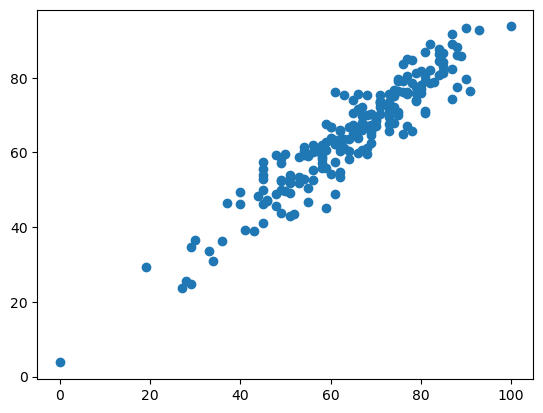

In [28]:
plt.scatter(y_test,y_pred)


In [29]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
